In [1]:
words = open('words.txt', 'r').read().splitlines()

In [2]:
words[:10]

['abakus',
 'abandon',
 'abazja',
 'abażur',
 'abażurek',
 'abdukcja',
 'abduktor',
 'abdykacja',
 'abdykowanie',
 'abecadło']

In [3]:
len(words)

48178

In [4]:
min(len(w) for w in words)

3

In [5]:
print(min(words, key=len))

aga


In [6]:
max(len(w) for w in words)

25

In [7]:
print(max(words, key=len))

osiemdziesięciotysięcznik


## Bigrams

In [8]:
b = {}

for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1    # if not present 0, else curr+1
        #print(ch1, ch2)

In [9]:
b

{('<S>', 'a'): 1998,
 ('a', 'b'): 708,
 ('b', 'a'): 992,
 ('a', 'k'): 1552,
 ('k', 'u'): 776,
 ('u', 's'): 1125,
 ('s', '<E>'): 643,
 ('a', 'n'): 12097,
 ('n', 'd'): 554,
 ('d', 'o'): 1482,
 ('o', 'n'): 2885,
 ('n', '<E>'): 1126,
 ('a', 'z'): 557,
 ('z', 'j'): 214,
 ('j', 'a'): 2299,
 ('a', '<E>'): 12832,
 ('a', 'ż'): 376,
 ('ż', 'u'): 70,
 ('u', 'r'): 1142,
 ('r', '<E>'): 1455,
 ('r', 'e'): 1729,
 ('e', 'k'): 2492,
 ('k', '<E>'): 3511,
 ('b', 'd'): 30,
 ('d', 'u'): 290,
 ('u', 'k'): 530,
 ('k', 'c'): 212,
 ('c', 'j'): 1623,
 ('k', 't'): 659,
 ('t', 'o'): 3069,
 ('o', 'r'): 2933,
 ('d', 'y'): 807,
 ('y', 'k'): 1311,
 ('k', 'a'): 6759,
 ('a', 'c'): 2545,
 ('k', 'o'): 3974,
 ('o', 'w'): 6434,
 ('w', 'a'): 6601,
 ('n', 'i'): 19698,
 ('i', 'e'): 20247,
 ('e', '<E>'): 15024,
 ('b', 'e'): 609,
 ('e', 'c'): 1991,
 ('c', 'a'): 1071,
 ('a', 'd'): 1717,
 ('d', 'ł'): 232,
 ('ł', 'o'): 1222,
 ('o', '<E>'): 1813,
 ('e', 'r'): 3896,
 ('r', 'r'): 64,
 ('r', 'a'): 4036,
 ('b', 'i'): 1327,
 ('e', 't'):

In [10]:
sorted(b.items(), key=lambda kv: -kv[1])

[(('i', 'e'), 20247),
 (('n', 'i'), 19698),
 (('e', '<E>'), 15024),
 (('a', '<E>'), 12832),
 (('a', 'n'), 12097),
 (('<S>', 'p'), 7076),
 (('k', 'a'), 6759),
 (('w', 'a'), 6601),
 (('o', 'w'), 6434),
 (('e', 'n'), 6098),
 (('r', 'o'), 4688),
 (('z', 'e'), 4517),
 (('r', 'z'), 4475),
 (('s', 't'), 4441),
 (('c', 'z'), 4366),
 (('<S>', 'k'), 4366),
 (('i', 'a'), 4155),
 (('a', 'r'), 4148),
 (('r', 'a'), 4036),
 (('z', 'a'), 4030),
 (('k', 'o'), 3974),
 (('e', 'r'), 3896),
 (('p', 'o'), 3701),
 (('<S>', 's'), 3550),
 (('k', '<E>'), 3511),
 (('n', 'a'), 3423),
 (('w', 'i'), 3273),
 (('t', 'a'), 3250),
 (('s', 'z'), 3092),
 (('p', 'r'), 3073),
 (('t', 'o'), 3069),
 (('<S>', 'w'), 3055),
 (('n', 'o'), 2957),
 (('o', 'r'), 2933),
 (('o', 'n'), 2885),
 (('a', 't'), 2877),
 (('l', 'i'), 2821),
 (('c', 'i'), 2790),
 (('<S>', 'o'), 2725),
 (('<S>', 'z'), 2676),
 (('o', 'd'), 2560),
 (('a', 'c'), 2545),
 (('o', 'ś'), 2536),
 (('e', 'k'), 2492),
 (('t', 'r'), 2490),
 (('a', 'l'), 2469),
 (('c', 'h'

In [11]:
import torch

In [12]:
N = torch.zeros((34, 34), dtype=torch.int32)

In [13]:
len(set(''.join(words)))

33

In [14]:
chars = sorted(list(set(''.join(words))))

stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0

In [15]:
stoi

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'r': 17,
 's': 18,
 't': 19,
 'u': 20,
 'v': 21,
 'w': 22,
 'y': 23,
 'z': 24,
 'ó': 25,
 'ą': 26,
 'ć': 27,
 'ę': 28,
 'ł': 29,
 'ń': 30,
 'ś': 31,
 'ź': 32,
 'ż': 33,
 '.': 0}

In [16]:
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

In [17]:
itos = {i:s for s,i in stoi.items()}

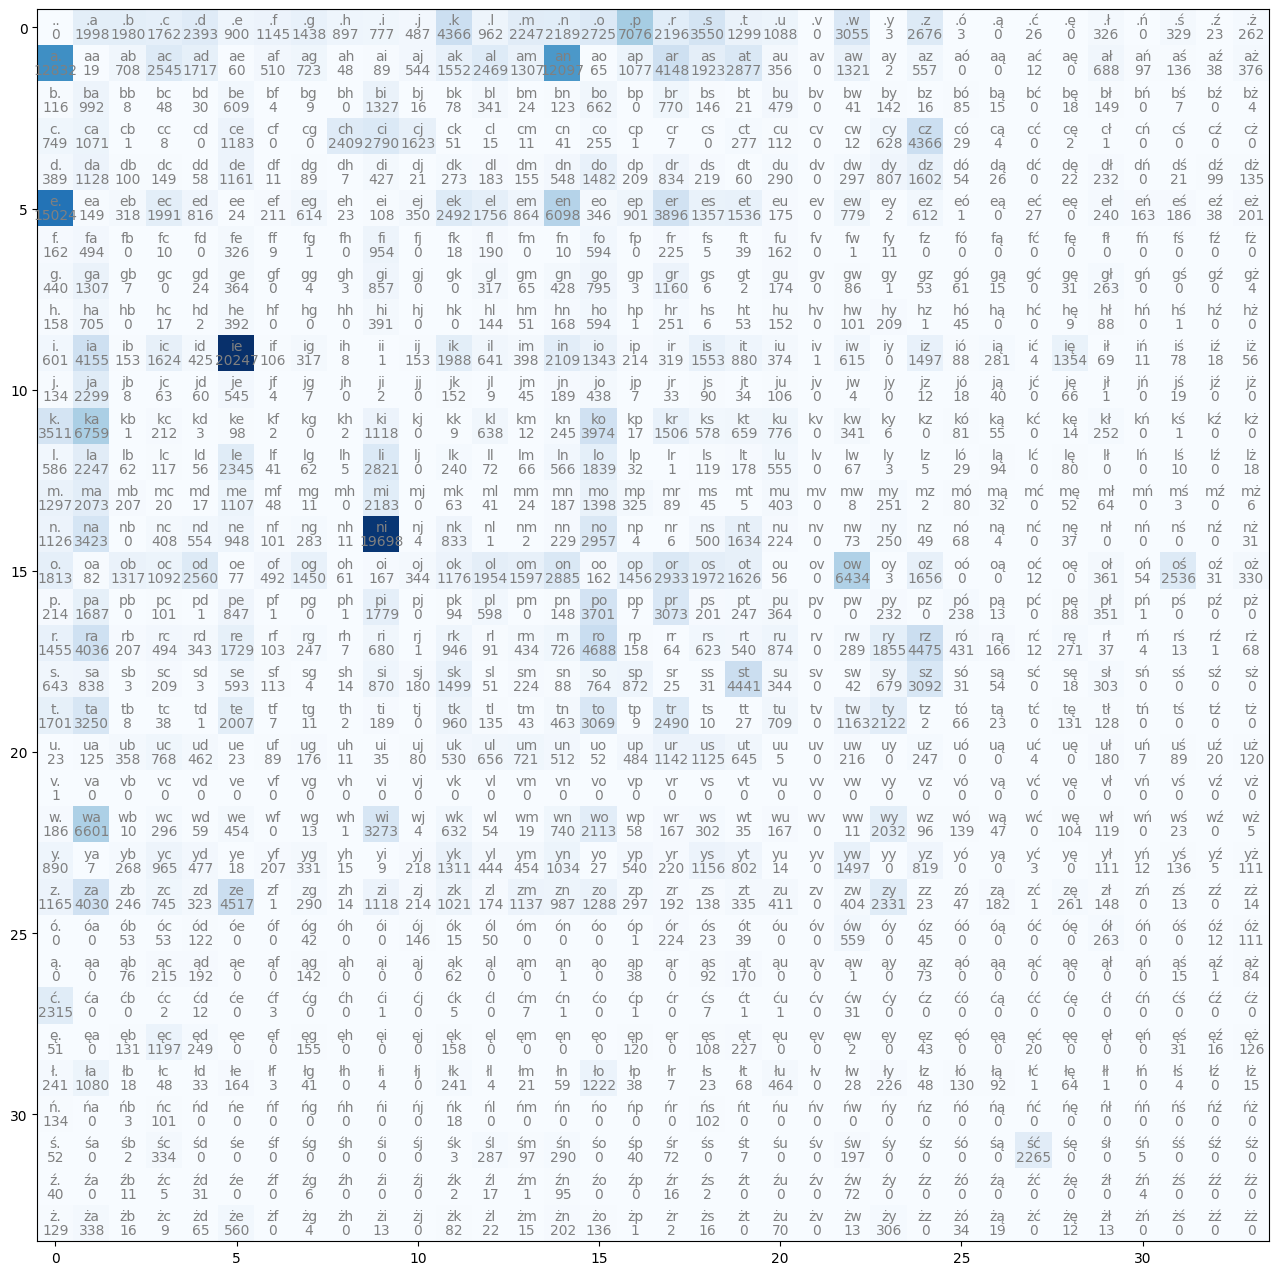

In [18]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(34):
    for j in range(34):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color="gray")
        plt.text(i, j, N[j, i].item(), ha="center", va="top", color="gray")

In [19]:
N[0]

tensor([   0, 1998, 1980, 1762, 2393,  900, 1145, 1438,  897,  777,  487, 4366,
         962, 2247, 2189, 2725, 7076, 2196, 3550, 1299, 1088,    0, 3055,    3,
        2676,    3,    0,   26,    0,  326,    0,  329,   23,  262],
       dtype=torch.int32)

In [20]:
p = N[0].float()
p = p / p.sum()
p

tensor([0.0000e+00, 4.1471e-02, 4.1098e-02, 3.6573e-02, 4.9670e-02, 1.8681e-02,
        2.3766e-02, 2.9848e-02, 1.8618e-02, 1.6128e-02, 1.0108e-02, 9.0622e-02,
        1.9968e-02, 4.6640e-02, 4.5436e-02, 5.6561e-02, 1.4687e-01, 4.5581e-02,
        7.3685e-02, 2.6963e-02, 2.2583e-02, 0.0000e+00, 6.3411e-02, 6.2269e-05,
        5.5544e-02, 6.2269e-05, 0.0000e+00, 5.3967e-04, 0.0000e+00, 6.7666e-03,
        0.0000e+00, 6.8288e-03, 4.7740e-04, 5.4382e-03])

In [21]:
g = torch.Generator().manual_seed(2147483647)
p = torch.rand(3, generator=g)
p = p/ p.sum()
p

tensor([0.6064, 0.3033, 0.0903])

In [22]:
torch.multinomial(p, num_samples=20, replacement=True, generator=g)

tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1])

In [23]:
g = torch.Generator().manual_seed(2147483647)

ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
itos[ix]

'.'

In [24]:
g = torch.Generator().manual_seed(2147483647)

for i in range(10):
    out = []
    ix = 0
    while True:
        p = N[ix].float()
        p = p / p.sum()
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break

    print(''.join(out))

doje.
strolia.
gie.
kaniek.
na.
niz.
zcypotk.
kogarątwczopnie.
plapowarzgręskngan.
an.


In [25]:
P = (N+1).float()   # model smoothing
print(P.sum(1, keepdim=True).shape)  
P /= P.sum(1, keepdim=True)

torch.Size([34, 1])


In [26]:
P[0].sum()

tensor(1.)

In [27]:
g = torch.Generator().manual_seed(2147483647)

for i in range(50):
    out = []
    ix = 0
    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break

    print(''.join(out))

doje.
strolia.
gie.
kaniek.
na.
niz.
zcypotk.
kogarątwczopnie.
plapowarzgręskngan.
an.
emorkohimasz.
j.
ludnodk.
jan.
a.
st.
wykadakanie.
dżelole.
polniczuterelia.
sninieokałanie.
dłanieremafie.
kagale.
nienydma.
hadniegnęcza.
k.
lie.
dem.
papietar.
akowatesymienitęciniecze.
twynfiruwak.
sprzykaniekadłumia.
wpe.
żlen.
dczadzałujacanitweniezozywiomiekle.
chosmieufie.
omaciedyrzanie.
wilkotła.
lus.
asmo.
scietwiekauenienopógicjm.
nieogewiz.
perzmb.
en.
gałka.
arprzle.
prtoniwa.
ma.
m.
lek.
ninotaprd.


In [28]:
log_likelihood = 0
n = 0

#for w in words[:3]:
for w in ["volcano"]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1,  ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1
        print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')

print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n}')   # <- loss

.v: 0.0000 -10.7834
vo: 0.0286 -3.5553
ol: 0.0532 -2.9330
lc: 0.0096 -4.6507
ca: 0.0684 -2.6829
an: 0.2376 -1.4374
no: 0.0883 -2.4268
o.: 0.0494 -3.0079
log_likelihood=tensor(-31.4773)
nll=tensor(31.4773)
3.9346656799316406


In [29]:
xs, ys = [], []

for w in words[:1]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        print(ch1, ch2)
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

. a
a b
b a
a k
k u
u s
s .


In [30]:
xs

tensor([ 0,  1,  2,  1, 11, 20, 18])

In [31]:
ys

tensor([ 1,  2,  1, 11, 20, 18,  0])

In [32]:
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes=34).float()
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0

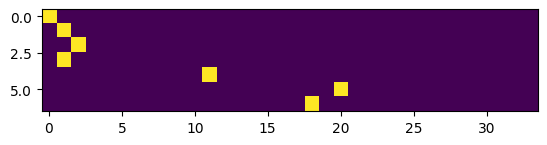

In [33]:
plt.imshow(xenc)

In [34]:
xenc.dtype

torch.float32

In [35]:
W = torch.randn((34, 34))
xenc @ W

tensor([[-2.5241,  0.2396,  0.5419,  0.2454, -0.0611,  0.0634,  1.3024,  0.7061,
         -0.7926, -0.1097,  0.8994,  0.4757,  0.1044, -0.3789, -0.7125, -0.1469,
          0.7492, -0.9138, -0.0384,  2.5666,  0.3334, -0.3323,  0.8848, -0.2600,
         -0.4636, -0.1085, -0.6686, -0.1169,  0.3629, -0.0394,  0.5570,  0.4262,
         -0.7760, -1.8562],
        [ 1.0914, -2.1908,  1.2053, -0.1319, -0.1105, -0.2079,  0.8482, -1.3531,
         -1.6295, -1.2543, -1.2079, -1.0444,  1.1267, -0.4526,  1.2785,  0.3822,
          0.5894,  1.3657,  0.4657, -0.9744, -0.0624,  0.0622, -0.3142,  1.2059,
          1.0821,  1.9200,  0.7611, -1.2679, -1.2677,  2.6118,  0.6660,  0.4657,
          0.5678, -0.6539],
        [-0.2370,  1.3126,  0.2809,  0.0851,  0.1924, -1.0962, -0.7674,  2.1110,
          0.3099,  0.5167,  0.6733,  0.0544,  0.6437,  0.8764, -0.2999,  1.4747,
         -0.0559,  0.2071, -1.4038,  0.3388, -1.3542, -1.5269, -0.5252,  2.3654,
         -1.5464,  0.0280,  0.6123,  1.1514, -0.1492,

In [36]:
logits = xenc @ W   # log-counts
counts = logits.exp()   # N
probs = counts / counts.sum(1, keepdims=True)
probs

tensor([[0.0016, 0.0246, 0.0333, 0.0247, 0.0182, 0.0206, 0.0712, 0.0392, 0.0088,
         0.0173, 0.0476, 0.0312, 0.0215, 0.0133, 0.0095, 0.0167, 0.0410, 0.0078,
         0.0186, 0.2521, 0.0270, 0.0139, 0.0469, 0.0149, 0.0122, 0.0174, 0.0099,
         0.0172, 0.0278, 0.0186, 0.0338, 0.0296, 0.0089, 0.0030],
        [0.0443, 0.0017, 0.0497, 0.0130, 0.0133, 0.0121, 0.0348, 0.0038, 0.0029,
         0.0042, 0.0044, 0.0052, 0.0459, 0.0095, 0.0534, 0.0218, 0.0268, 0.0583,
         0.0237, 0.0056, 0.0140, 0.0158, 0.0109, 0.0497, 0.0439, 0.1015, 0.0319,
         0.0042, 0.0042, 0.2027, 0.0290, 0.0237, 0.0263, 0.0077],
        [0.0122, 0.0574, 0.0204, 0.0168, 0.0187, 0.0052, 0.0072, 0.1275, 0.0210,
         0.0259, 0.0303, 0.0163, 0.0294, 0.0371, 0.0114, 0.0675, 0.0146, 0.0190,
         0.0038, 0.0217, 0.0040, 0.0034, 0.0091, 0.1644, 0.0033, 0.0159, 0.0285,
         0.0488, 0.0133, 0.0673, 0.0045, 0.0048, 0.0569, 0.0127],
        [0.0443, 0.0017, 0.0497, 0.0130, 0.0133, 0.0121, 0.0348, 0.0038, 

In [37]:
probs[0].sum()

tensor(1.)

In [38]:
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((34, 34), generator=g)

In [39]:
xenc = F.one_hot(xs, num_classes=34).float()
logits = xenc @ W
counts = logits.exp()
probs = counts / counts.sum(1, keepdims=True)
probs

tensor([[0.0543, 0.0089, 0.0110, 0.0038, 0.0151, 0.0110, 0.0024, 0.0207, 0.0123,
         0.0280, 0.0071, 0.0249, 0.0082, 0.0073, 0.0447, 0.2127, 0.0540, 0.0022,
         0.0223, 0.0049, 0.0303, 0.0098, 0.0026, 0.0177, 0.0105, 0.1375, 0.1305,
         0.0058, 0.0033, 0.0153, 0.0039, 0.0234, 0.0119, 0.0419],
        [0.0090, 0.0086, 0.0033, 0.0700, 0.0059, 0.0676, 0.0076, 0.0159, 0.0141,
         0.0279, 0.0053, 0.0615, 0.0363, 0.0317, 0.0211, 0.0035, 0.0225, 0.0447,
         0.0344, 0.0062, 0.0232, 0.0074, 0.0293, 0.0321, 0.0081, 0.0091, 0.0229,
         0.0162, 0.0071, 0.0043, 0.0511, 0.0083, 0.1147, 0.1692],
        [0.0091, 0.0366, 0.0395, 0.0970, 0.0075, 0.0110, 0.0103, 0.1227, 0.0254,
         0.0575, 0.0114, 0.0230, 0.0067, 0.0742, 0.0163, 0.0054, 0.0787, 0.0294,
         0.0600, 0.0090, 0.0061, 0.0546, 0.0057, 0.0247, 0.0252, 0.0046, 0.0103,
         0.0672, 0.0089, 0.0158, 0.0054, 0.0239, 0.0077, 0.0092],
        [0.0090, 0.0086, 0.0033, 0.0700, 0.0059, 0.0676, 0.0076, 0.0159, 

In [40]:
probs.shape

torch.Size([7, 34])

In [41]:
nlls = torch.zeros(7)   # negative log likelihoods
for i in range(7):
    x = xs[i].item()
    y = ys[i].item()

    p = probs[i, y]
    logp = torch.log(p)
    nll = -logp
    nlls[i] = nll

print(nlls.mean().item())   # loss

3.7735366821289062


### How does loss work

In [42]:
xs

tensor([ 0,  1,  2,  1, 11, 20, 18])

In [43]:
ys

tensor([ 1,  2,  1, 11, 20, 18,  0])

In [44]:
probs[0, 1], probs[1, 2], probs[2, 1], probs[3, 11] # etc

(tensor(0.0089), tensor(0.0033), tensor(0.0366), tensor(0.0615))

In [45]:
torch.arange(7)

tensor([0, 1, 2, 3, 4, 5, 6])

In [46]:
probs[torch.arange(7), ys]

tensor([0.0089, 0.0033, 0.0366, 0.0615, 0.0998, 0.0879, 0.0058])

In [47]:
loss = -probs[torch.arange(7), ys].log().mean()

### how training works


In [48]:
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((34, 34), generator=g, requires_grad=True)

In [49]:
# forward pass
xenc = F.one_hot(xs, num_classes=34).float()
logits = xenc @ W
counts = logits.exp()
probs = counts / counts.sum(1, keepdims=True)
loss = -probs[torch.arange(7), ys].log().mean()

In [50]:
print(loss.item())

3.7735366821289062


In [51]:
# backward pass
W.grad = None   # zero the gradient
loss.backward()

In [52]:
W.grad

tensor([[ 0.0078, -0.1416,  0.0016,  ...,  0.0033,  0.0017,  0.0060],
        [ 0.0026,  0.0024, -0.1419,  ...,  0.0024,  0.0328,  0.0483],
        [ 0.0013, -0.1376,  0.0056,  ...,  0.0034,  0.0011,  0.0013],
        ...,
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]])

In [53]:
W.grad.shape, W.shape

(torch.Size([34, 34]), torch.Size([34, 34]))

In [54]:
# update
W.data -= 0.1 * W.grad

In [55]:
# forward pass
xenc = F.one_hot(xs, num_classes=34).float()
logits = xenc @ W
counts = logits.exp()
probs = counts / counts.sum(1, keepdims=True)
loss = -probs[torch.arange(7), ys].log().mean()

In [56]:
print(loss.item())     # SMALLER LOSS!

3.7594432830810547


### actual training

In [57]:
xs, ys = [], []

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print(num)

g = torch.Generator().manual_seed(2147483647)
W = torch.randn((34, 34), generator=g, requires_grad=True)

500441


In [58]:
for k in range(100):
    # forward pass
    xenc = F.one_hot(xs, num_classes=34).float()
    logits = xenc @ W
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdims=True)
    loss = -probs[torch.arange(num), ys].log().mean()
    print(loss.item())

    # backward pass
    W.grad = None
    loss.backward()

    # update
    W.data -= 50 * W.grad

4.012693881988525
3.563789129257202
3.2906973361968994
3.144312858581543
3.037355661392212
2.951982259750366
2.8834352493286133
2.8281211853027344
2.7829086780548096
2.745435953140259
2.7139999866485596
2.6873319149017334
2.664464235305786
2.6446571350097656
2.62734317779541
2.6120853424072266
2.5985419750213623
2.5864434242248535
2.5755717754364014
2.5657520294189453
2.556840181350708
2.548717737197876
2.5412869453430176
2.534464120864868
2.528179883956909
2.5223746299743652
2.5169970989227295
2.512003183364868
2.507354497909546
2.503016948699951
2.4989609718322754
2.495159864425659
2.4915904998779297
2.488232135772705
2.4850666522979736
2.4820775985717773
2.4792497158050537
2.4765701293945312
2.474027156829834
2.4716103076934814
2.4693098068237305
2.4671170711517334
2.465024948120117
2.4630255699157715
2.4611129760742188
2.4592816829681396
2.4575259685516357
2.455841064453125
2.4542224407196045
2.4526665210723877
2.45116925239563
2.4497275352478027
2.448338031768799
2.446997404098510

## Sampling

In [59]:
# before

g = torch.Generator().manual_seed(2147483647)

for i in range(10):
    out = []
    ix = 0
    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

doje.
strolia.
gie.
kaniek.
na.
niz.
zcypotk.
kogarątwczopnie.
plapowarzgręskngan.
an.


In [ ]:
# with neural network

g = torch.Generator().manual_seed(2147483647)

for i in range(10):
    out = []
    ix = 0
    while True:
        xenc = F.one_hot(torch.tensor([ix]), num_classes=34).float()
        logits = xenc @ W
        counts = logits.exp()
        p = counts / counts.sum(1, keepdims=True)

        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

doje.
strolia.
gie.
kaniek.
na.
niz.
zcypotk.
kogarąłoniopnie.
plapowarzgręskngan.
an.
